In [1]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json
import math


folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index"


In [2]:

# Open and read the JSON file
with open("best_models_grid_search_3d.json", "r") as json_file:
    output_dict = json.load(json_file)

# Print the contents (optional)
# for dataset, indices in output_dict.items():
#     print(f"Dataset: {dataset}")
#     for index, model in indices.items():
#         print(f"  Index: {index}, Best Model: {model}")

### Parameters

In [3]:
# baselines = ['bmtree', 'kdtree', 'ketree_greddy', 'qdtree', 'r_star_tree', 'rankspace_zorder', 'rlrtree', 'rtree', 'zorder']
join_result_path = "../result/libspatialindex/HDD/4K/{name}/join/"
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"

baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000_3d', 
                   'kdtree':'_3d',
                   'platon':'_3d',
                   'zm':'_bits_32_3d',
                   'kdtree_greedy':'_3d',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_400_3d',
                   'r_star_tree':'_rstar_3d',
                   'rankspace_zorder':'_bits_32_3d',
                   'rlrtree':'_rlrtree_epoch_8_sample_10000_3d',
                   'rtree':'_quadratic_3d',
                   'lisa':'_3d',
                   'zorder':'_bits_32_3d'}


data_names = ["nyc_100000000_3d", "data_100000000_3_skewed_4"]
display_data_names = ["NYC", "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_3_uniform_1_0.001x0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_3_uniform_1_0.001x0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']
baselines = ['rtree', 'r_star_tree',  'kdtree', 'kdtree_greedy','zorder', 'rankspace_zorder']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'kdtree', 'kdtree_greedy', 'waffle', 'qdtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'qdtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'lisa', 'qdtree']
display_baselines = ['RT', 'RST', 'KD', 'KDG','ZR', 'ZRR']
display_baselines = ['RT', 'RST', 'RLR', 'KD', 'KDG', 'QD','ZR', 'ZRR', 'BMT']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']
# display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Waffle', 'Qd-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree']
display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree','ZR-tree', 'ZRR-tree', 'ZM-index', 'BM-tree', 'Kd-tree', 'GKd-tree', 'LISA', 'Qd-tree']

#### 3D

../result/libspatialindex/HDD/4K/bmtree/build/nyc_100000000_3d_nyc_100000000_3d_range_1000_3_uniform_1_0.001x0.001x0.001_bits_32_depth_10_sample_10000_3d.txt
../result/libspatialindex/HDD/4K/bmtree/build/data_100000000_3_skewed_4_range_1000_3_uniform_1_0.001x0.001x0.001_bits_32_depth_10_sample_10000_3d.txt
../result/libspatialindex/HDD/4K/kdtree_greedy/build/nyc_100000000_3d_nyc_100000000_3d_range_1000_3_uniform_1_0.001x0.001x0.001_3d.txt
../result/libspatialindex/HDD/4K/kdtree_greedy/build/data_100000000_3_skewed_4_range_1000_3_uniform_1_0.001x0.001x0.001_3d.txt


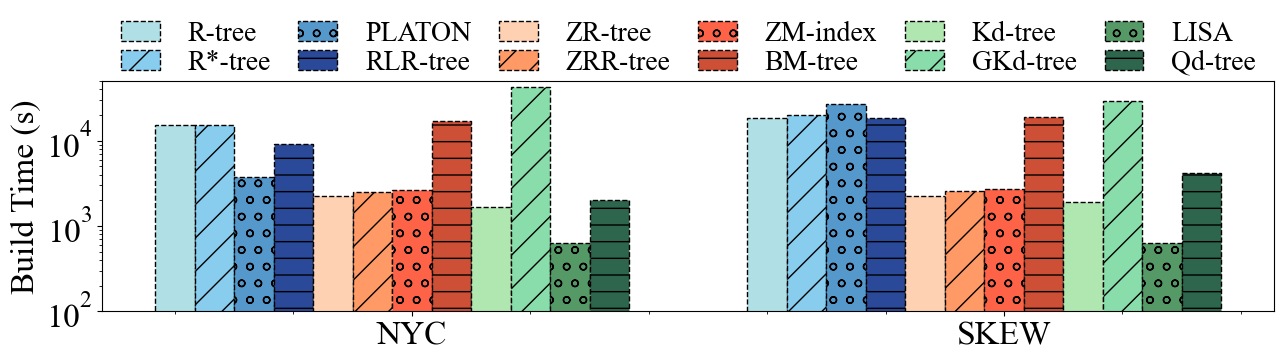

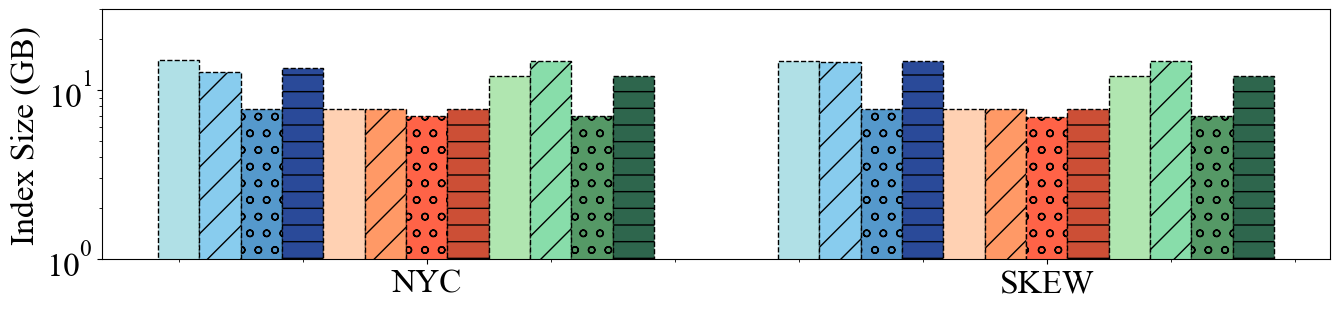

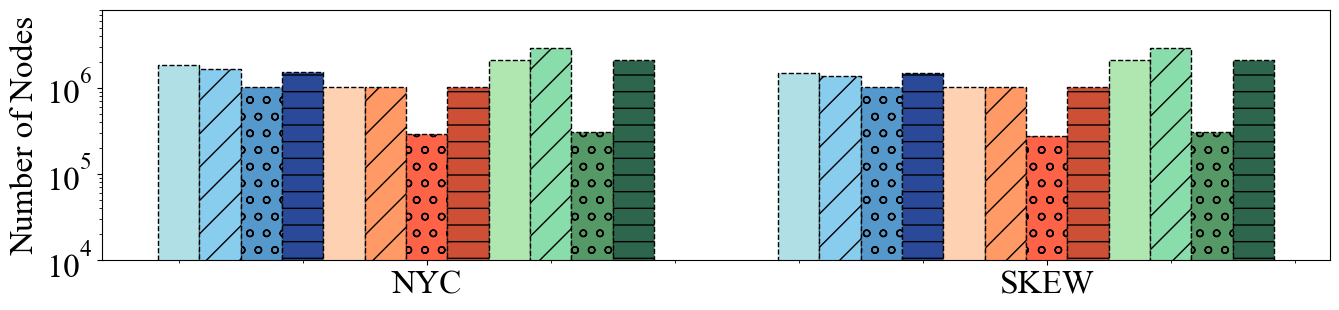

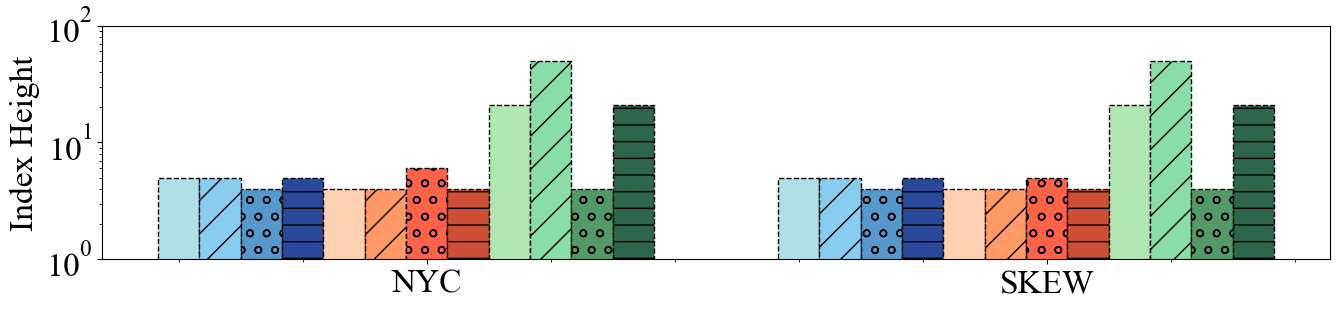

In [4]:
result = []
utilization_result = []
splits_result = []
adjustments_result = []
index_size = []
node_number = []
tree_height = []
build = []

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_utilization_results = []
    dataset_splits_results = []
    dataset_adjustments_results = []
    dataset_index_size = []
    dataset_node_number = []
    dataset_tree_height = []
    dataset_build = []
    
    for i, data_name in enumerate(data_names):

        # if baseline in output_dict[display_data_names[i]].keys():
        #     suffix = output_dict[display_data_names[i]][baseline]
        #     print(suffix)
        
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline), build_result_name)
        
        tree_property = parse_rtree_properties(res)
        
        # dataset_results.append({
        #     'ElapsedTime': tree_property.ElapsedTime,
        #     'ElapsedBuildTime': tree_property.ElapsedBuildTime,
        #     'ElapsedLearnTime': tree_property.ElapsedLearnTime
        # })

        dataset_build.append([int(tree_property.ElapsedLearnTime / 1e9 / 60) , int(tree_property.ElapsedBuildTime / 1e9 / 60)])
        # print(tree_property.ElapsedTime, tree_property.ElapsedLearnTime)
        dataset_results.append(float(tree_property.ElapsedTime / 1e9))
        dataset_utilization_results.append(tree_property.Utilization)
        dataset_splits_results.append(tree_property.Splits)
        dataset_adjustments_results.append(tree_property.Adjustments / 1e6)
        dataset_index_size.append((tree_property.TreeDatSize + tree_property.TreeIdxSize) / (1024 * 1024 * 1024))
        dataset_node_number.append(tree_property.NumberOfNodes)
        dataset_tree_height.append(tree_property.TreeHeight)
        # print(baseline, data_name, tree_property.Utilization)
        if baseline == 'kdtree_greedy' or baseline == 'bmtree':
            print(res)

    # if baseline == 'r_star_tree':
    #     print(dataset_tree_height)

    result.append(dataset_results) 
    utilization_result.append(dataset_utilization_results) 
    splits_result.append(dataset_splits_results) 
    adjustments_result.append(dataset_adjustments_results) 
    # print(baseline, dataset_adjustments_results)
    index_size.append(dataset_index_size)
    node_number.append(dataset_node_number)
    tree_height.append(dataset_tree_height)
    build.append(dataset_build)

plot_hist(display_data_names, display_baselines, result, y_label="Build Time (s)", is_log=True,  output_file_paths=
          [folder + "/exp_sigmod/build_3d.pdf", "../figs/exp_sigmod/build_3d.png"],bottom=1e2, top=5e4, legend_location="top")

plot_hist(display_data_names, display_baselines, index_size, y_label="Index Size (GB)", is_legend=False, is_log=True,  output_file_paths=
          [folder + "/exp_sigmod/index_size_3d.pdf", "../figs/exp_sigmod/index_size_3d.png"],bottom=1, top=30, legend_location="top")

plot_hist(display_data_names, display_baselines, node_number, y_label="Number of Nodes", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/node_number_3d.pdf", "../figs/exp_sigmod/node_number_3d.png"],bottom=1e4, top=8e6, legend_location="top")

plot_hist(display_data_names, display_baselines, tree_height, y_label="Index Height", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/tree_height_3d.pdf", "../figs/exp_sigmod/tree_height_3d.png"],bottom=1, top=100, legend_location="top")


[81068.913169785, 29239.421584585]
[107802.449696015, 240.063238675]
platon [[4, 4], [2, 4]]
[61.111625505000006, 1405.33023201]
[12225.78045307, 32304.55099898]
[905.43683259, 1331.806151765]
[3178.62024579, 3935.416839055]
[226.937, 124290.843]
[204.525523905, 176.79647828]
[6891.422015365, 7563.1850129800005]
[4587.00726192, 4859.1664430149995]
[82.702469495, 82.702469495]
../result/libspatialindex/HDD/4K/qdtree/point/nyc_100000000_3d_nyc_100000000_3d_range_1000_3_uniform_1_0.001x0.001x0.001_nyc_100000000_3d_point_200000_3_uniform_1_episode_10_sampling_ratio_0.0001_action_space_400_3d.txt
../result/libspatialindex/HDD/4K/qdtree/point/data_100000000_3_skewed_4_range_1000_3_uniform_1_0.001x0.001x0.001_point_200000_data_100000000_3_skewed_4_3_uniform_1_episode_10_sampling_ratio_0.0001_action_space_400_3d.txt
[599.483788645, 14617.319049295002]


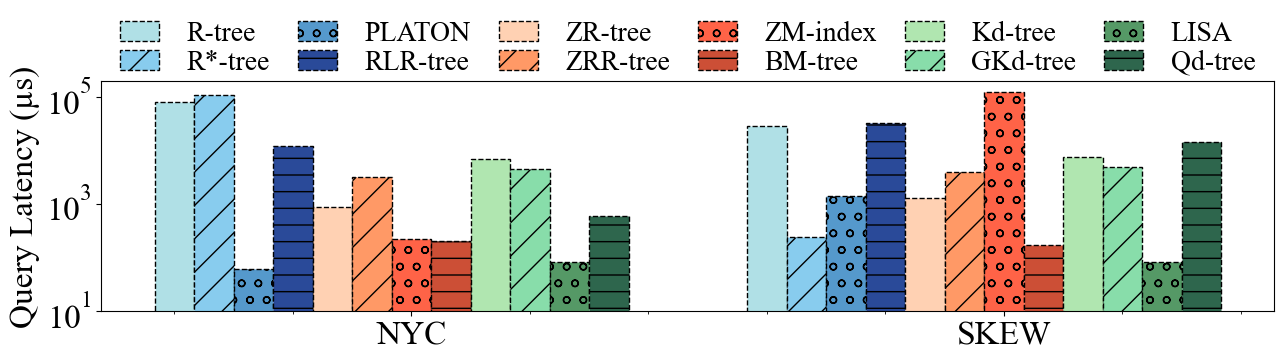

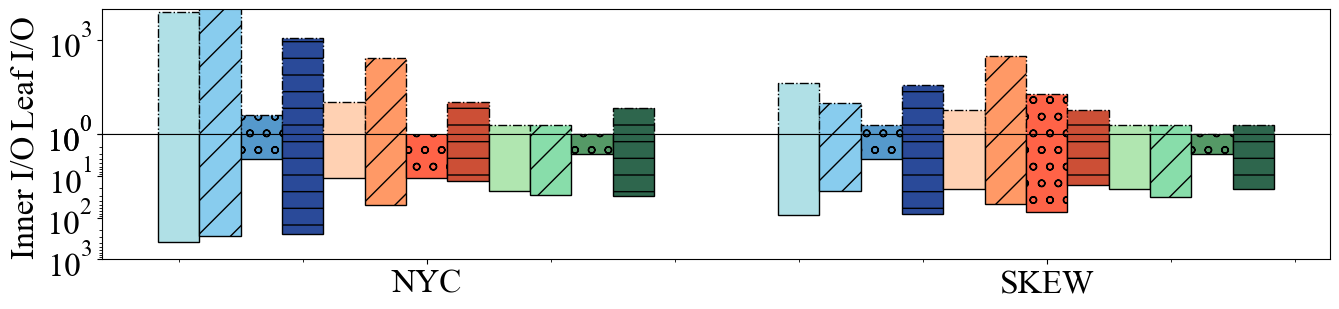

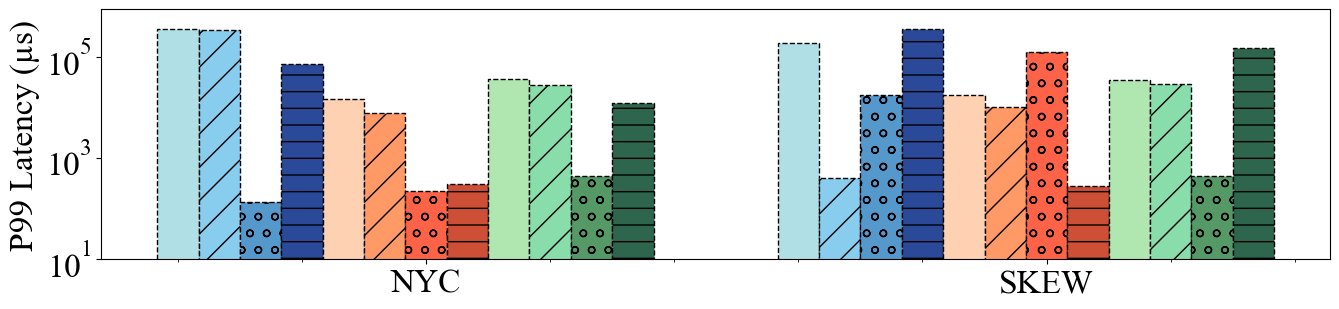

In [13]:
# 1 
# default_range_name = "_{data_name}_range_1000_2_normal_1_0.001x0.001"
real_point_name = "{data_name}_point_200000_3_uniform_1"
synthetic_point_name = "point_200000_{data_name}_3_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']

result = []
query_result_num = []
IO = []
P99 = []
P50 = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for i, data_name in enumerate(data_names):

        # if baseline in output_dict[display_data_names[i]].keys():
        #     suffix = output_dict[display_data_names[i]][baseline]

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
        
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline), point_result_name)
        if baseline == "qdtree":
            print(res)
        tree_property = parse_rtree_properties(res)

        # self.QueryNum = kwargs.get('Query num', None)
        # self.QueryMean = kwargs.get('Query mean', None)
        # self.QueryVariance = kwargs.get('Query variance', None)
        # self.QueryStdDev = kwargs.get('Query stdDev', None)
        # self.QueryP50 = kwargs.get('Query p50', None)
        # self.QueryP99 = kwargs.get('Query p99', None)
        

 
        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append((tree_property.IndexIo + tree_property.LeafIo) / 200000)
        dataset_IO.append([math.ceil(tree_property.LeafIo / tree_property.QueryNum), math.ceil(tree_property.IndexIo / tree_property.QueryNum)])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
        # if baseline == 'zm':
        #     print(dataset_IO)

        # if baseline == 'rankspace_zorder' or baseline == 'bmtree':
        #     print(baseline + " " + str(float(tree_property.QueryMean / 1000)))
    
    result.append(dataset_results) 
    query_result_num.append(dataset_result_num)
    if baseline == 'platon':
        print("platon", dataset_IO)
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage

    print(dataset_results)

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)",  is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_query_3d.pdf", "../figs/exp_sigmod/point_query_3d.png"], bottom=1e1, top=2*1e5, legend_location="top")

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_IO_3d.pdf", "../figs/exp_sigmod/point_IO_3d.png"], legend_labels=["Leaf I/O", "Inner I/O"], 
                bottom1=1, top1=1e4, bottom2=1, top2=1e3, legend_location="top")

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/point_query_P99_3d.pdf", "../figs/exp_sigmod/point_query_P99_3d.png"], bottom=1e1, top=9*1e5, legend_location="top")


[6399330.453516, 403889.612537]
[199189.72485, 57.878767999999994]
platon [[2971.234, 57.527], [4.075, 3.254]]
platon [126610.903, 40580.275]
[29417.705497000003, 1359.397205]
[593107.074869, 511324.810441]
[50893.990385, 932.8448440000001]
rankspace_zorder [[6759.797, 132.649], [91.277, 11.361]]
[75208.254304, 1234.764181]
[154.952, 76.56]
[2207.917754, 167.89327]
[155604.492326, 3235.4211880000003]
[91289.376317, 366.986579]
[752.304847, 752.304847]
[291219.5113, 153886.13433700002]


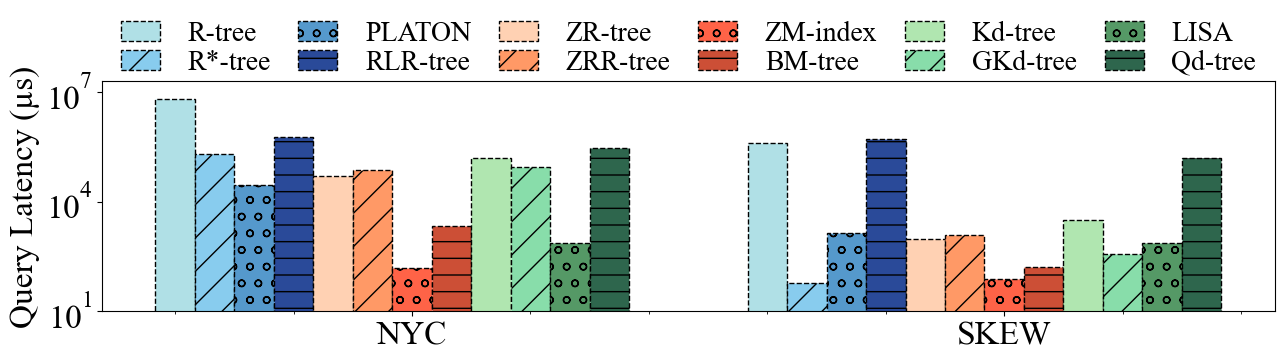

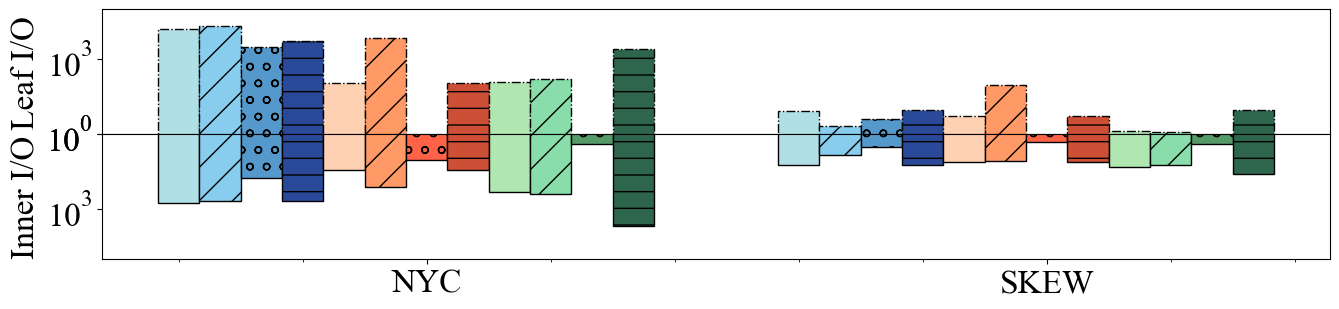

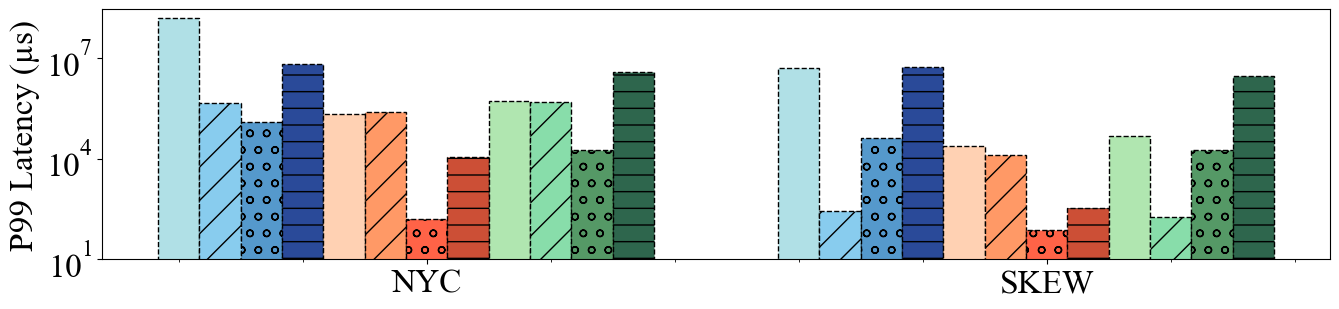

In [12]:
real_range_name_pattern = "_{data_name}_range_1000_3_uniform_1_0.001x0.001x0.001"
synthetic_range_name_pattern = "_range_1000_3_uniform_1_0.001x0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"
result = []
IO = []

P99 = []
P50 = []

query_result_num = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for i, data_name in enumerate(data_names):

        # if baseline in output_dict[display_data_names[i]].keys():
        #     suffix = output_dict[display_data_names[i]][baseline]
            # print(suffix)
            
        if data_name.startswith("data"):
            range_name = synthetic_range_name_pattern
        else:
            range_name=real_range_name_pattern.format(data_name=data_name)
        
        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline), range_result_name)

        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # dataset_IO.append((tree_property.IndexIo + tree_property.LeafIo)/1000)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
    if baseline == 'platon':
        print("platon", dataset_IO)
        print("platon", dataset_P99)
    if baseline == 'rankspace_zorder':
        print("rankspace_zorder", dataset_IO) 
    result.append(dataset_results) 
    query_result_num.append(dataset_result_num) 
    IO.append(dataset_IO)
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage

    print(dataset_results)

# # print(IO)
# for item in result:
#     print(item)


# plot_hist(display_data_names, display_baselines, query_result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/range_query_result_num.pdf", "../figs/exp/range_query_result_num.png"])

# plot_hist(data_names, baselines, result)

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_time_3d.pdf", "../figs/exp_sigmod/range_query_time_3d.png"], bottom=1e1, top=2*1e7, legend_location="top")

# plot_hist(display_data_names, display_baselines, IO, y_label="I/O", output_file_paths=
#           [folder + "/figs/range_query_IO.pdf", "../figs/exp/range_query_IO.png"])

# plot_hist_stack(display_data_names, display_baselines, IO, y_label="I/O", is_log=True, output_file_paths=
#           [folder + "/figs/range_query_IO.pdf", "../figs/exp/range_query_IO.png"], legend_labels=["Leaf I/O", "Inner I/O"], legend_location="right")

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_IO_3d.pdf", "../figs/exp_sigmod/range_query_IO_3d.png"], legend_labels=["Leaf I/O", "Inner I/O"],
                bottom1=1, top1=100000, bottom2=1, top2=100000, legend_location="top")

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/range_query_P99_3d.pdf", "../figs/exp_sigmod/range_query_P99_3d.png"], bottom=1e1, top=3*1e8, legend_location="top")

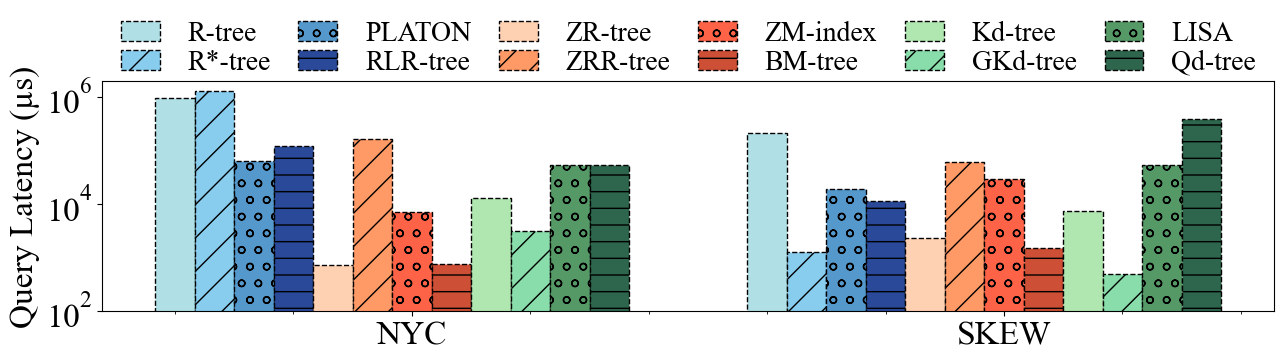

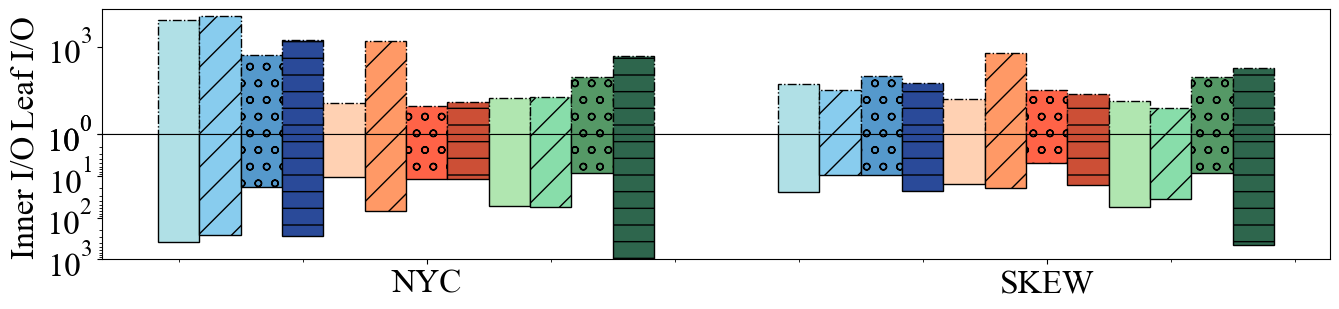

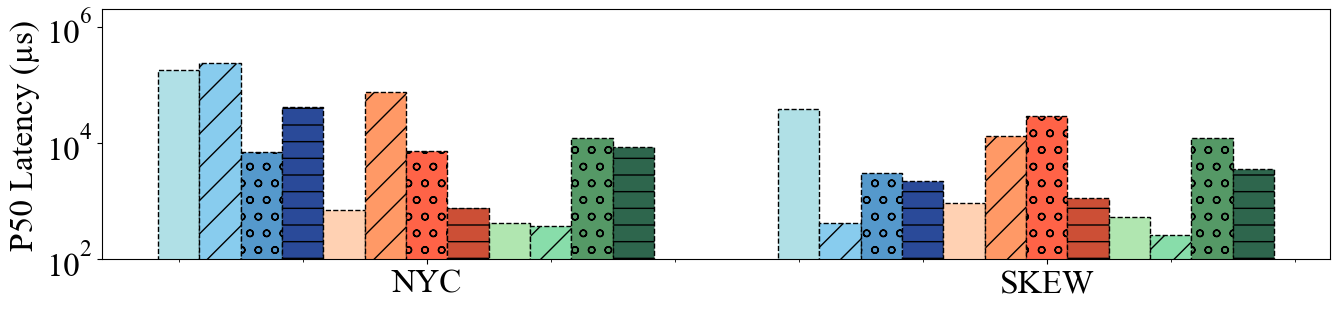

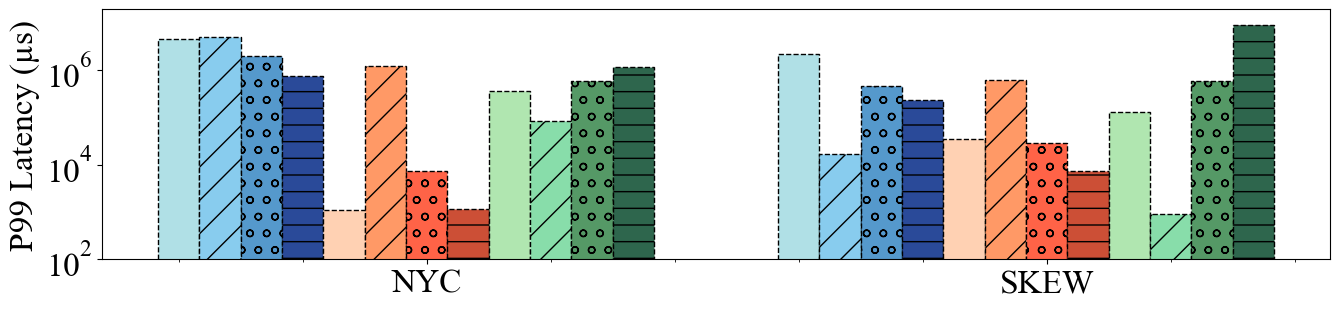

In [11]:
# 1 
data_name = "us_100000000"
k=25
real_knn_name = "{data_name}_knn_1000_3_uniform_1"
synthetic_knn_name = "knn_1000_3_uniform_1"
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']

result = []
result_num = []
IO = []

P99 = []
P50 = []

QueryPercentage = {}

for baseline in baselines:
    suffix = baseline_suffix[baseline]
    dataset_results = []
    dataset_result_num = []
    dataset_IO = []
    dataset_P50 = []
    dataset_P99 = []
    dataset_percentage = []
    for data_name in data_names:

        # if baseline in output_dict[display_data_names[i]].keys():
        #     suffix = output_dict[display_data_names[i]][baseline]
        #     print(suffix)

        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            knn_name = synthetic_knn_name
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            knn_name = real_knn_name.format(data_name=data_name)
        
        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline), knn_result_name)
        
        tree_property = parse_rtree_properties(res)

        dataset_results.append(float(tree_property.QueryMean / 1000))
        dataset_result_num.append(tree_property.QueryResults)
        # print(tree_property.QueryNum, data_name, baseline)
        dataset_IO.append([tree_property.LeafIo / tree_property.QueryNum, tree_property.IndexIo / tree_property.QueryNum])
        dataset_P50.append(tree_property.QueryP50 / 1000)
        dataset_P99.append(tree_property.QueryP99 / 1000)
        dataset_percentage.append([item / 1000 for item in tree_property.QueryPercentage])
        
    result.append(dataset_results) 
    result_num.append(dataset_result_num) 
    IO.append(dataset_IO) 
    P50.append(dataset_P50)
    P99.append(dataset_P99)
    QueryPercentage[baseline] = dataset_percentage
    
# for item in result:
#     print(item)

# print(IO)
# plot_hist(display_data_names, display_baselines, result_num, y_label="Result Num", output_file_paths=
#           [folder + "/figs/knn_num.pdf", "../figs/exp/knn_num.png"])

plot_hist(display_data_names, display_baselines, result, y_label="Query Latency (µs)", is_legend=True, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_time_3d.pdf", "../figs/exp_sigmod/knn_query_time_3d.png"], bottom=1e2, top=2*1e6, legend_location="top")

plot_hist_stack_mirrored(display_data_names, display_baselines, IO, y_label="I/O", is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_IO_3d.pdf", "../figs/exp_sigmod/knn_query_IO_3d.png"], legend_labels=["Leaf I/O", "Inner I/O"],legend_location="right", 
                bottom1=1, top1=2*1e4, bottom2=1, top2=1e3)

plot_hist(display_data_names, display_baselines, P50, y_label="P50 Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P50_3d.pdf", "../figs/exp_sigmod/knn_query_P50_3d.png"], bottom=1e2, top=2*1e6)

plot_hist(display_data_names, display_baselines, P99, y_label="P99 Latency (µs)",is_legend=False, is_log=True, output_file_paths=
          [folder + "/exp_sigmod/knn_query_P99_3d.pdf", "../figs/exp_sigmod/knn_query_P99_3d.png"], bottom=1e2, top=2*1e7)